# Load data

In [1]:
import json

with open("/Users/wnowogorski/PycharmProjects/CHAT_AGH/notebooks/entities.json", "r") as f:
    entities = json.load(f)

with open("/Users/wnowogorski/PycharmProjects/CHAT_AGH/notebooks/relationships.json", "r") as f:
    relationships = json.load(f)

In [2]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from collections import Counter
import re
from IPython.display import display, HTML

# Set visualization style
plt.style.use('ggplot')
sns.set(style="whitegrid")

In [3]:
entities_df = pd.DataFrame(entities)
relationships_df = pd.DataFrame(relationships)

In [4]:
print(f"Number of entities records: {len(entities_df)}")
print(f"Number of relationships records: {len(relationships_df)}")

Number of entities records: 6712
Number of relationships records: 4407


In [5]:
entities_df.head(5)

,entity_name,entity_type,entity_description
0,ERHARD BUSEK,[PERSON],"Austrian politician and intellectual, Vice-Cha..."
1,AGH,[ORGANIZATION],Akademia Górniczo-Hutnicza im. Stanisława Stas...
2,Wiedeń,[ORGANIZATION],"Vienna University, where Erhard Busek graduate..."
3,DOCTOR HONORIS CAUSA AGH,[DEGREE],Honorary doctorate awarded by AGH
4,SENAT AGH,[COMMITTEE],"The Senate of AGH, which approved the awarding..."


# Preprocessing

Group entities

In [14]:
grouped_entities = entities_df.groupby('entity_name').agg({
    'entity_type': lambda x: sum(x, []),
    'entity_description': list,
})
grouped_entities

,entity_type,entity_description
entity_name,,
#JESTEMZAGH,[EVENT],[An AGH-related action or campaign]
#JESTEMZAGH COTTON BAG,"[RESOURCE, RESOURCE]",[Cotton bag with the #jestemzAGH initiative na...
#JESTEMZAGH MUG,[RESOURCE],"[White ceramic mug, black on the inside, with ..."
#JESTEMZAGH NECK GAITER,[RESOURCE],[Black neck gaiter with the #jestemzAGH inscri...
#JESTEMZAGH PIN,"[RESOURCE, RESOURCE]","[Pin with the #jestemzAGH initiative name, ava..."
...,...,...
ТЕХНОЛОГІЇ ПРОМИСЛОВОСТІ 4.0,[COURSE],[Course of study]
ТРАНСПОРТ В ПРОМИСЛОВОСТІ 4.0,[COURSE],[Course of study]
ХІМІЧНІ ТЕХНОЛОГІЇ,[COURSE],[Course of study]


Filter entities

# EDA

## Entities

In [15]:
print(f"Number of entities: {len(grouped_entities)}")

Number of entities: 5100


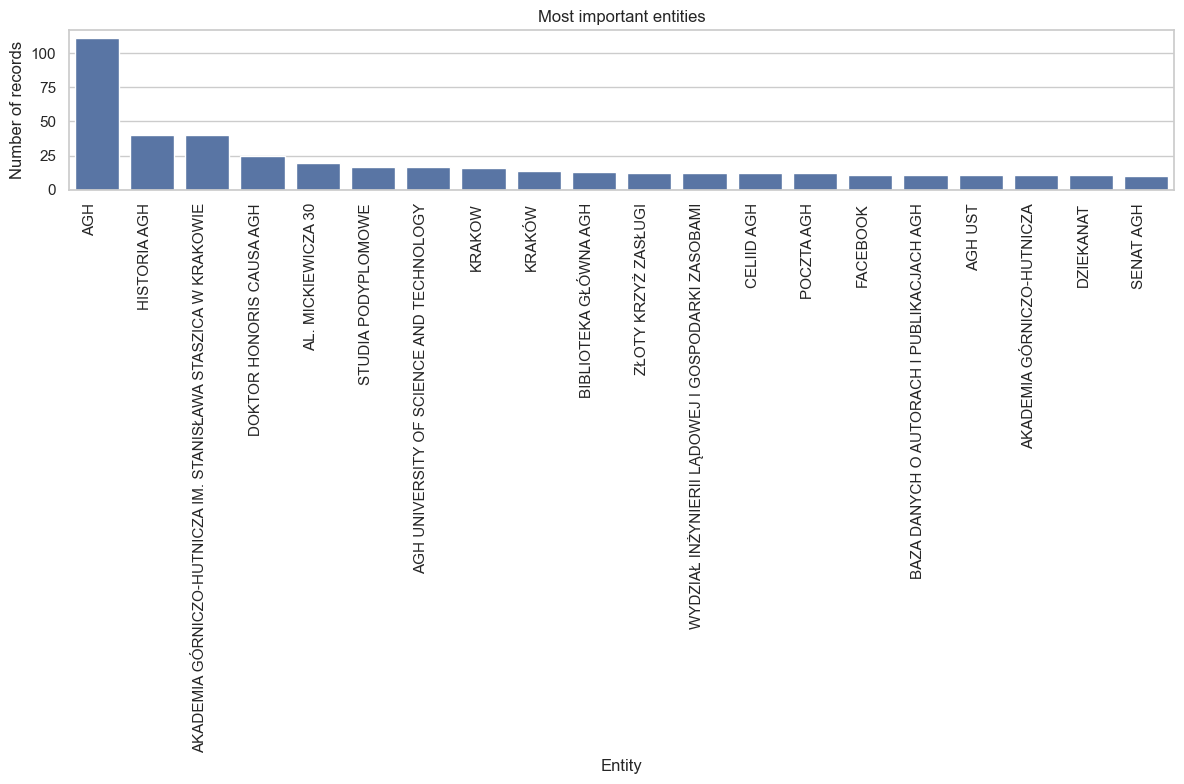

In [16]:
grouped_entities["num_records"] = grouped_entities["entity_description"].apply(len)

top_20 = grouped_entities.sort_values(by='num_records', ascending=False).head(20)

plt.figure(figsize=(12, 8))
sns.barplot(x=top_20.index, y=top_20['num_records'])

plt.xticks(rotation=90, ha="right")

plt.xlabel('Entity')
plt.ylabel('Number of records')
plt.title('Most important entities')
plt.tight_layout()

plt.show()

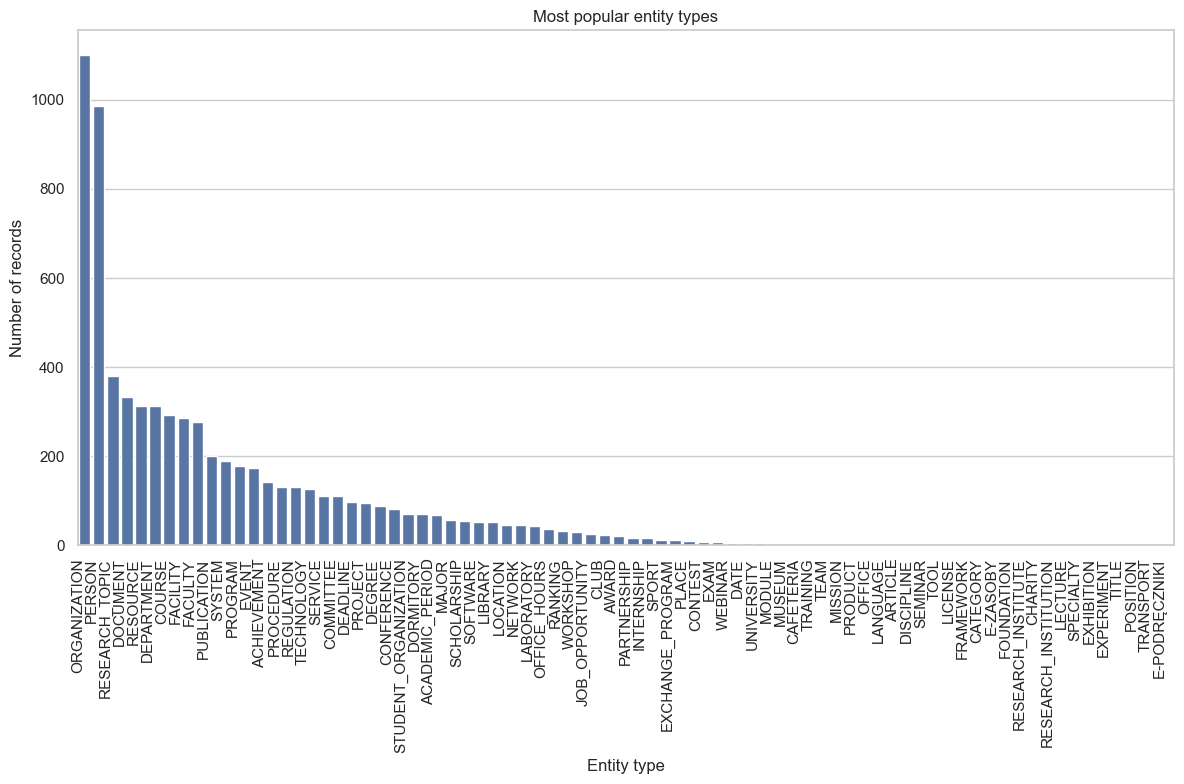

In [17]:
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

types_count = Counter()

for types in grouped_entities["entity_type"]:
    for t in types:
        types_count.update([t])

sorted_types = sorted(types_count.items(), key=lambda x: x[1], reverse=True)
sorted_keys = [k for k, v in sorted_types]
sorted_values = [v for k, v in sorted_types]

plt.figure(figsize=(12, 8))
sns.barplot(x=sorted_keys, y=sorted_values)

plt.xticks(rotation=90, ha="right")
plt.xlabel('Entity type')
plt.ylabel('Number of records')
plt.title('Most popular entity types')
plt.tight_layout()
plt.show()


## Relationships

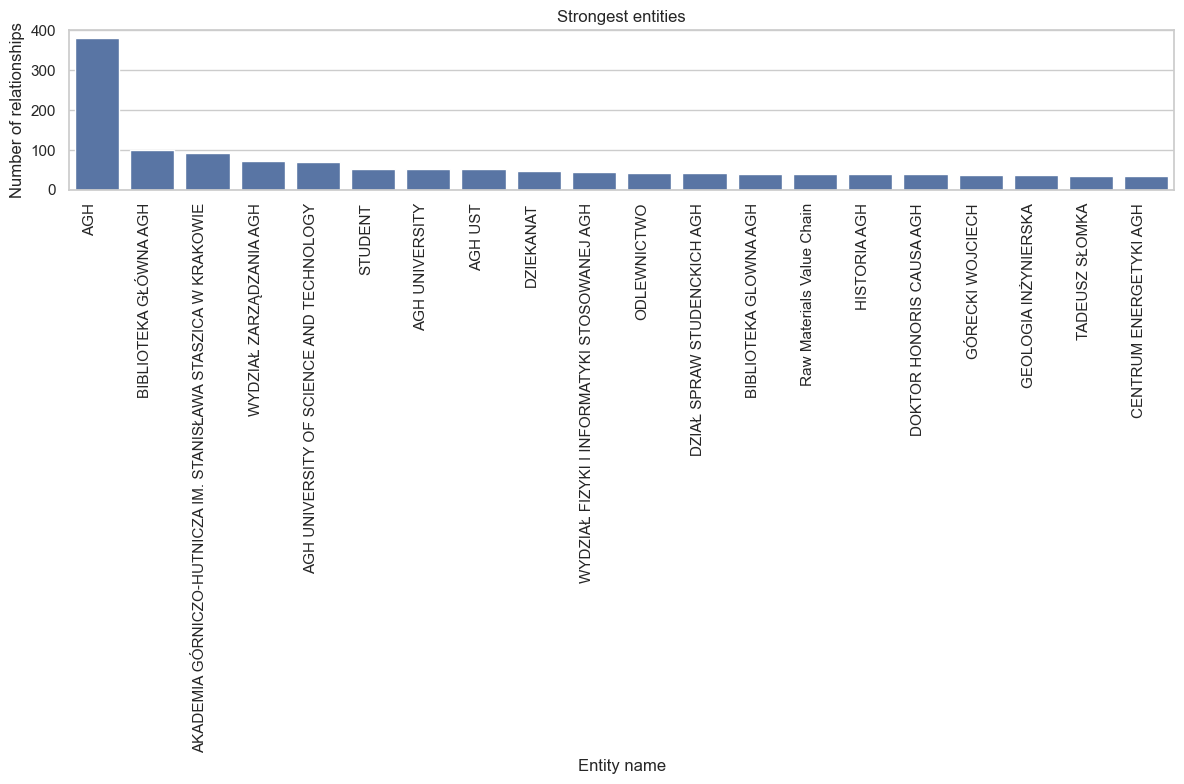

In [30]:
relationships_counter = Counter()

relationships_counter.update(relationships_df["source_entity"])
relationships_counter.update(relationships_df["target_entity"])

most_common = relationships_counter.most_common(20)

plt.figure(figsize=(12, 8))
sns.barplot(x=[c[0] for c in most_common], y=[c[1] for c in most_common])

plt.xticks(rotation=90, ha="right")
plt.xlabel('Entity name')
plt.ylabel('Number of relationships')
plt.title('Strongest entities')
plt.tight_layout()
plt.show()

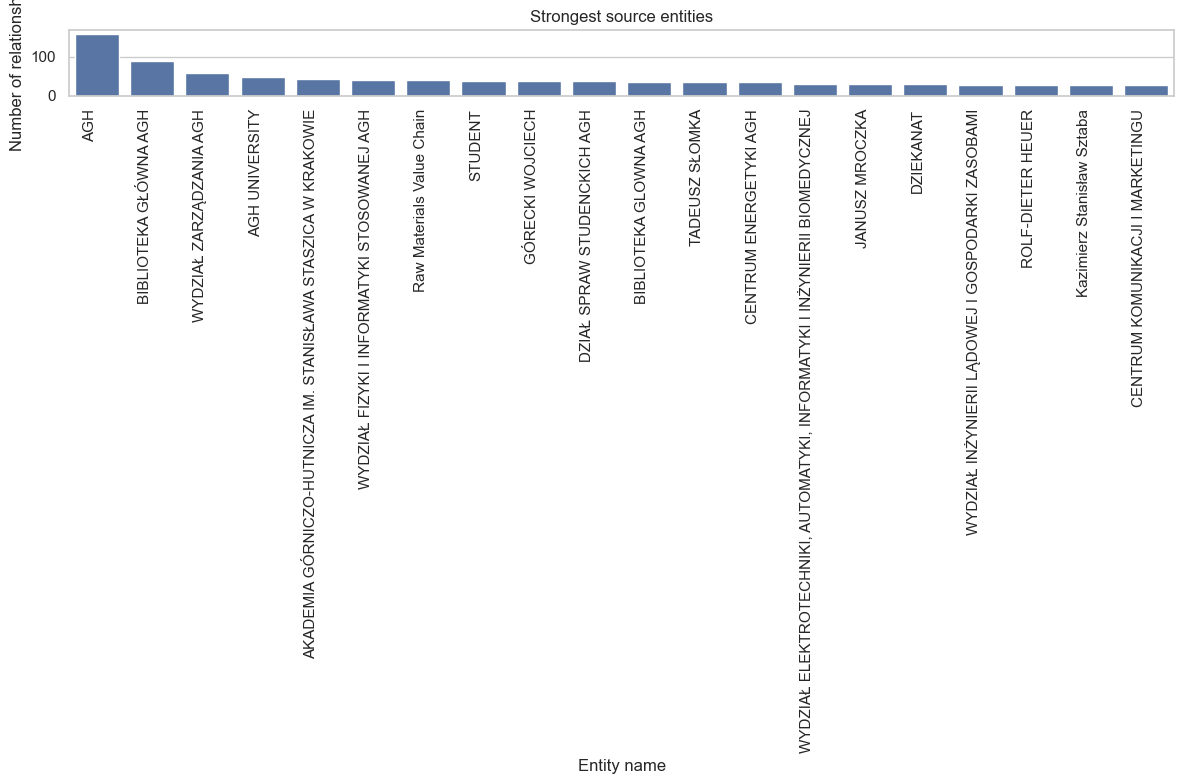

In [31]:
relationships_counter = Counter()

relationships_counter.update(relationships_df["source_entity"])

most_common = relationships_counter.most_common(20)

plt.figure(figsize=(12, 8))
sns.barplot(x=[c[0] for c in most_common], y=[c[1] for c in most_common])

plt.xticks(rotation=90, ha="right")
plt.xlabel('Entity name')
plt.ylabel('Number of relationships')
plt.title('Strongest source entities')
plt.tight_layout()
plt.show()

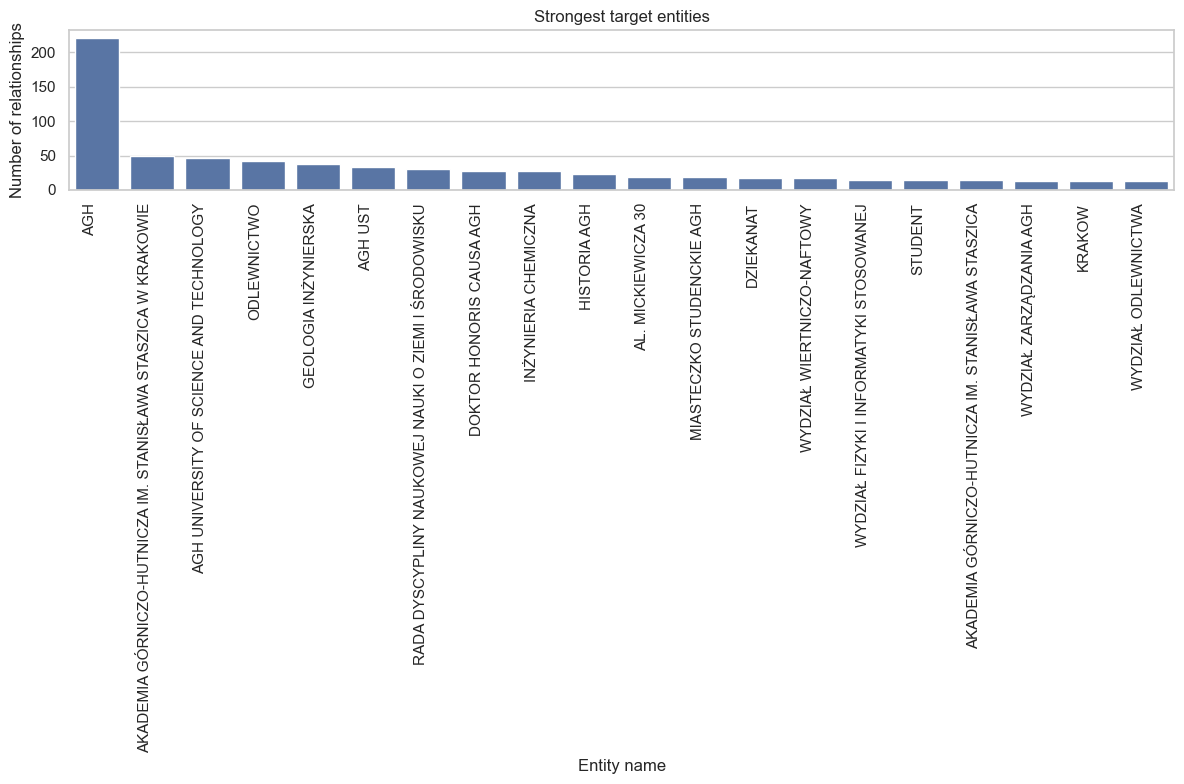

In [32]:
relationships_counter = Counter()

relationships_counter.update(relationships_df["target_entity"])

most_common = relationships_counter.most_common(20)

plt.figure(figsize=(12, 8))
sns.barplot(x=[c[0] for c in most_common], y=[c[1] for c in most_common])

plt.xticks(rotation=90, ha="right")
plt.xlabel('Entity name')
plt.ylabel('Number of relationships')
plt.title('Strongest target entities')
plt.tight_layout()
plt.show()

In [34]:
import pandas as pd
import networkx as nx
from pyvis.network import Network

G = nx.from_pandas_edgelist(
    relationships_df,
    source='source_entity',
    target='target_entity',
    edge_attr='relationship_description',
    create_using=nx.DiGraph()
)

# Use Pyvis for interactive visualization
net = Network(height="750px", width="100%", notebook=True, directed=True)
net.from_nx(G)
net.show("graph.html")


graph.html
